# 👔 The Supervisor Pattern — One Agent to Manage Them All

**Video:** *Agentic Design Patterns Part 2: Supervisor* | **Channel:** Prashant Nair (@prashantnairofficial)

---

### The Pattern:
```
Supervisor → Researcher → Supervisor → Writer → Supervisor → Editor → Supervisor → DONE
```

### What We're Building:
An **AI Content Team** with a Supervisor orchestrating three specialists:
- **Researcher** — gathers structured information on the topic
- **Writer** — transforms research into a blog post
- **Editor** — polishes the draft for publication

### The Analogy:
The Supervisor is the editor-in-chief. It never writes a word. It decides WHO does WHAT and WHEN.

---

**Tech Stack:** LangGraph, LangChain, OpenAI (gpt-4o-mini)  
**Author:** Prashant Nair | AI & GenAI Practitioner | Principal Trainer

## 📦 Step 1: Install Dependencies

In [1]:
!pip install --quiet langchain==0.3.25 langchain-core==0.3.62 langchain-openai==0.3.18 langgraph==0.3.34 grandalf

import langchain, langgraph


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.4/438.4 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.2/148.2 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 105.5 MB/s eta 0:00:00


## 🔐 Step 2: Configure OpenAI

In [2]:
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
print("✅ OpenAI API key configured")

✅ OpenAI API key configured


## 🏗️ Step 3: Define the State

The state tracks the task, outputs from each specialist, and workflow progress.

In [3]:
from typing import TypedDict, Optional

class ContentTeamState(TypedDict):
    topic: str                         # The content topic
    research: str                      # Researcher's output
    draft: str                         # Writer's output
    final_content: str                 # Editor's output
    current_step: str                  # Track workflow progress
    workflow_log: list[str]            # Log of all Supervisor decisions

print("✅ State schema defined")
print("   Fields: topic, research, draft, final_content, current_step, workflow_log")

✅ State schema defined
   Fields: topic, research, draft, final_content, current_step, workflow_log


## 🧑‍🔬 Step 4: Build the Specialist Agents

Three specialists, each with a clear role, clear inputs, and clear outputs.

In [4]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.4)

# ── RESEARCHER ──
def researcher(state: ContentTeamState) -> ContentTeamState:
    print(f"\n{'═' * 60}")
    print(f"🔬 RESEARCHER — Gathering information")
    print(f"{'═' * 60}")

    response = llm.invoke([
        SystemMessage(content="""You are a thorough research specialist. Your job is to gather comprehensive information on a given topic.

Produce structured research notes that include:
1. Core definition and key concepts
2. Why this topic matters (with specific reasons)
3. Key components or steps involved
4. Real-world use cases (at least 3 concrete examples)
5. Common challenges or pitfalls
6. Best practices
7. Relevant statistics or data points if applicable

Format your output as clear, structured research notes — NOT a blog post. Use headers and bullet points.
Be factual, specific, and thorough."""),
        HumanMessage(content=f"Research the following topic thoroughly:\n\nTOPIC: {state['topic']}")
    ])

    research = response.content
    print(f"   ✅ Research complete ({len(research)} chars)")
    print(f"\n   Preview: {research[:300]}...")

    return {
        **state,
        "research": research,
        "current_step": "research_done",
        "workflow_log": state["workflow_log"] + ["Researcher: gathered information on topic"],
    }


# ── WRITER ──
def writer(state: ContentTeamState) -> ContentTeamState:
    print(f"\n{'═' * 60}")
    print(f"✍️  WRITER — Creating blog post")
    print(f"{'═' * 60}")

    response = llm.invoke([
        SystemMessage(content="""You are a skilled technical blog writer. Your job is to transform research notes into an engaging, well-structured blog post.

Writing guidelines:
- Start with a compelling hook that draws the reader in
- Use clear section headers (##) to organize content
- Write in a professional but conversational tone
- Include practical examples and actionable insights
- Keep paragraphs short (3-4 sentences max)
- End with a strong conclusion and call to action
- Target length: 800-1200 words

ONLY use information from the research notes provided. Do NOT hallucinate facts or statistics."""),
        HumanMessage(content=f"""Write a blog post based on these research notes:

TOPIC: {state['topic']}

RESEARCH NOTES:
{state['research']}""")
    ])

    draft = response.content
    print(f"   ✅ Draft complete ({len(draft)} chars, ~{len(draft.split())} words)")
    print(f"\n   Preview: {draft[:300]}...")

    return {
        **state,
        "draft": draft,
        "current_step": "draft_done",
        "workflow_log": state["workflow_log"] + ["Writer: created blog post from research"],
    }


# ── EDITOR ──
def editor(state: ContentTeamState) -> ContentTeamState:
    print(f"\n{'═' * 60}")
    print(f"📝 EDITOR — Polishing and finalizing")
    print(f"{'═' * 60}")

    response = llm.invoke([
        SystemMessage(content="""You are a meticulous editor. Your job is to polish a blog post draft into publication-ready content.

Editing checklist:
1. Fix any grammar, spelling, or punctuation errors
2. Improve sentence flow and readability
3. Ensure consistent tone (professional but accessible)
4. Tighten verbose sentences — every word must earn its place
5. Verify logical flow between sections
6. Add or improve section transitions
7. Ensure the introduction hooks the reader
8. Ensure the conclusion is strong and actionable
9. Format with proper markdown (headers, bold for emphasis, bullet points where appropriate)

Return the COMPLETE edited blog post. Do not summarize or truncate."""),
        HumanMessage(content=f"""Edit and polish this blog post draft:

DRAFT:
{state['draft']}""")
    ])

    final = response.content
    print(f"   ✅ Editing complete ({len(final)} chars, ~{len(final.split())} words)")
    print(f"\n   Preview: {final[:300]}...")

    return {
        **state,
        "final_content": final,
        "current_step": "editing_done",
        "workflow_log": state["workflow_log"] + ["Editor: polished draft into final content"],
    }


print("✅ Three specialists defined:")
print("   🔬 Researcher — gathers structured information")
print("   ✍️  Writer — creates blog post from research")
print("   📝 Editor — polishes draft for publication")

✅ Three specialists defined:
   🔬 Researcher — gathers structured information
   ✍️  Writer — creates blog post from research
   📝 Editor — polishes draft for publication


## 👔 Step 5: Build the Supervisor

The Supervisor **decides**, it doesn't **do**. It looks at the current state and routes to the next specialist.

We'll show two approaches:
- **Deterministic** (if/else logic) — predictable, easy to debug
- **LLM-powered** (bonus) — more flexible, the LLM chooses the next step

In [5]:
# ── SUPERVISOR (Deterministic Routing) ──

def supervisor(state: ContentTeamState) -> ContentTeamState:
    """The Supervisor decides which specialist to call next."""
    step = state.get("current_step", "start")

    print(f"\n{'─' * 60}")
    print(f"👔 SUPERVISOR — Evaluating state: '{step}'")

    if step == "start":
        decision = "We need research first. Routing to Researcher."
        next_step = "needs_research"
    elif step == "research_done":
        decision = "Research complete. Routing to Writer."
        next_step = "needs_writing"
    elif step == "draft_done":
        decision = "Draft complete. Routing to Editor."
        next_step = "needs_editing"
    elif step == "editing_done":
        decision = "All specialists have contributed. Content is ready. Terminating."
        next_step = "complete"
    else:
        decision = f"Unknown state '{step}'. Terminating."
        next_step = "complete"

    print(f"   📋 Decision: {decision}")
    print(f"{'─' * 60}")

    return {
        **state,
        "current_step": next_step,
        "workflow_log": state["workflow_log"] + [f"Supervisor: {decision}"],
    }


def route_from_supervisor(state: ContentTeamState) -> str:
    """Conditional edge: route based on Supervisor's decision."""
    step = state["current_step"]
    if step == "needs_research":
        return "researcher"
    elif step == "needs_writing":
        return "writer"
    elif step == "needs_editing":
        return "editor"
    else:
        return "end"


print("✅ Supervisor defined (deterministic routing)")
print("   Route logic: start → researcher → writer → editor → done")

✅ Supervisor defined (deterministic routing)
   Route logic: start → researcher → writer → editor → done


## 🔄 Step 6: Build the Graph

In [6]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(ContentTeamState)

# Add nodes
workflow.add_node("supervisor", supervisor)
workflow.add_node("researcher", researcher)
workflow.add_node("writer", writer)
workflow.add_node("editor", editor)

# Entry point: always start with Supervisor
workflow.set_entry_point("supervisor")

# Supervisor routes to specialists (conditional edges)
workflow.add_conditional_edges(
    "supervisor",
    route_from_supervisor,
    {
        "researcher": "researcher",
        "writer": "writer",
        "editor": "editor",
        "end": END,
    }
)

# Every specialist reports back to Supervisor
workflow.add_edge("researcher", "supervisor")
workflow.add_edge("writer", "supervisor")
workflow.add_edge("editor", "supervisor")

# Compile
content_team = workflow.compile()

print("✅ Content Team graph compiled!")
print("   Supervisor → [Researcher | Writer | Editor] → Supervisor → ... → END")

✅ Content Team graph compiled!
   Supervisor → [Researcher | Writer | Editor] → Supervisor → ... → END


## 📊 Step 7: Visualize the Star Topology

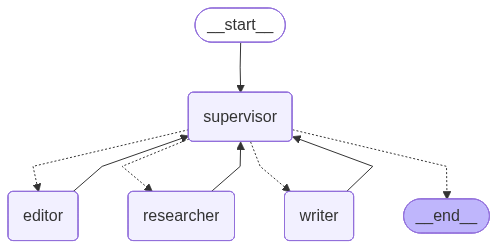

In [7]:
content_team

## 🚀 Step 8: Run It — Watch the AI Content Team

Give the team a topic and watch the Supervisor delegate to each specialist in sequence.

In [9]:
TOPIC = "RAG Pipelines for Enterprise: What They Are, Why They Matter, and How to Build Them"

print(f"📋 TOPIC: {TOPIC}")
print(f"\n🏁 Starting AI Content Team...")
print("\n" + "█" * 60)

result = content_team.invoke({
    "topic": TOPIC,
    "research": "",
    "draft": "",
    "final_content": "",
    "current_step": "start",
    "workflow_log": [],
})

print("\n" + "█" * 60)
print(f"\n🏁 CONTENT TEAM COMPLETE")
print(f"   Total Supervisor decisions: {len([l for l in result['workflow_log'] if l.startswith('Supervisor')])}")
print(f"   Specialists called: Researcher → Writer → Editor")
print(f"   Final content: {len(result['final_content'])} chars, ~{len(result['final_content'].split())} words")

📋 TOPIC: RAG Pipelines for Enterprise: What They Are, Why They Matter, and How to Build Them

🏁 Starting AI Content Team...

████████████████████████████████████████████████████████████

────────────────────────────────────────────────────────────
👔 SUPERVISOR — Evaluating state: 'start'
   📋 Decision: We need research first. Routing to Researcher.
────────────────────────────────────────────────────────────

════════════════════════════════════════════════════════════
🔬 RESEARCHER — Gathering information
════════════════════════════════════════════════════════════
   ✅ Research complete (4152 chars)

   Preview: # Research Notes on RAG Pipelines for Enterprise

## 1. Core Definition and Key Concepts
- **RAG Pipelines**: RAG stands for Retrieval-Augmented Generation. These pipelines integrate retrieval mechanisms with generative models to enhance the quality and relevance of generated content.
- **Key Concep...

────────────────────────────────────────────────────────────
👔 SUPERVISOR 

## 📄 Step 9: View the Final Blog Post

In [10]:
print("\n" + "═" * 60)
print("📄 FINAL BLOG POST (Research → Write → Edit pipeline):")
print("═" * 60)
print(result["final_content"])


════════════════════════════════════════════════════════════
📄 FINAL BLOG POST (Research → Write → Edit pipeline):
════════════════════════════════════════════════════════════
# RAG Pipelines for Enterprise: What They Are, Why They Matter, and How to Build Them

In today’s fast-paced digital landscape, businesses are constantly seeking ways to enhance operations and improve customer experiences. One of the most promising advancements in artificial intelligence is the development of Retrieval-Augmented Generation (RAG) pipelines. These innovative systems combine the power of data retrieval with generative models, resulting in more accurate, contextually relevant, and efficient content generation. But what exactly are RAG pipelines, and how can enterprises leverage them for success? Let’s dive in.

## Understanding RAG Pipelines

At its core, a RAG pipeline integrates three key processes: retrieval, augmentation, and generation.

- **Retrieval**: The first step involves fetching relevan

## 📊 Step 10: View the Workflow Log — Every Supervisor Decision

In [11]:
print("\n" + "═" * 60)
print("📊 WORKFLOW LOG — Supervisor's Decision Trail:")
print("═" * 60)

for i, entry in enumerate(result["workflow_log"], 1):
    icon = "👔" if entry.startswith("Supervisor") else "🔬" if "Researcher" in entry else "✍️" if "Writer" in entry else "📝"
    print(f"\n   {icon} Step {i}: {entry}")

print(f"\n{'═' * 60}")
print(f"Total steps: {len(result['workflow_log'])}")
print(f"Supervisor decisions: {len([l for l in result['workflow_log'] if l.startswith('Supervisor')])}")
print(f"Specialist outputs: {len([l for l in result['workflow_log'] if not l.startswith('Supervisor')])}")


════════════════════════════════════════════════════════════
📊 WORKFLOW LOG — Supervisor's Decision Trail:
════════════════════════════════════════════════════════════

   👔 Step 1: Supervisor: We need research first. Routing to Researcher.

   🔬 Step 2: Researcher: gathered information on topic

   👔 Step 3: Supervisor: Research complete. Routing to Writer.

   ✍️ Step 4: Writer: created blog post from research

   👔 Step 5: Supervisor: Draft complete. Routing to Editor.

   📝 Step 6: Editor: polished draft into final content

   👔 Step 7: Supervisor: All specialists have contributed. Content is ready. Terminating.

════════════════════════════════════════════════════════════
Total steps: 7
Supervisor decisions: 4
Specialist outputs: 3


## 🔬 Step 11: View Each Specialist's Output Separately

See what each agent produced at each stage of the pipeline.

In [12]:
outputs = [
    ("🔬 RESEARCHER OUTPUT", result["research"]),
    ("✍️  WRITER OUTPUT (Draft)", result["draft"]),
    ("📝 EDITOR OUTPUT (Final)", result["final_content"]),
]

for title, content in outputs:
    print(f"\n{'█' * 60}")
    print(f"  {title}")
    print(f"  Length: {len(content)} chars | ~{len(content.split())} words")
    print(f"{'█' * 60}")
    print(content[:800])
    if len(content) > 800:
        print(f"\n   ... [{len(content) - 800} more characters] ...")
    print()


████████████████████████████████████████████████████████████
  🔬 RESEARCHER OUTPUT
  Length: 4152 chars | ~579 words
████████████████████████████████████████████████████████████
# Research Notes on RAG Pipelines for Enterprise

## 1. Core Definition and Key Concepts
- **RAG Pipelines**: RAG stands for Retrieval-Augmented Generation. These pipelines integrate retrieval mechanisms with generative models to enhance the quality and relevance of generated content.
- **Key Concepts**:
  - **Retrieval**: The process of fetching relevant documents or data from a database or knowledge base.
  - **Augmentation**: Enhancing the generative model's output by incorporating retrieved information.
  - **Generation**: The use of AI models (like GPT) to create text or responses based on input data and retrieved information.

## 2. Why This Topic Matters
- **Enhanced Accuracy**: RAG pipelines improve the accuracy of generated content by grounding it in real data.
- **Contextual Rele

   ... [3352 more c

## 🧪 Step 12: Try Your Own Topic

In [ ]:
# ── Change the topic and run the Content Team on YOUR subject ──

YOUR_TOPIC = "The Future of Agentic AI in Healthcare: Opportunities and Challenges"

print(f"🔄 Running Content Team on: {YOUR_TOPIC}\n")

custom_result = content_team.invoke({
    "topic": YOUR_TOPIC,
    "research": "",
    "draft": "",
    "final_content": "",
    "current_step": "start",
    "workflow_log": [],
})

print(f"\n🏁 Done! Final content: ~{len(custom_result['final_content'].split())} words")
print(f"\n📄 FINAL BLOG POST:")
print(custom_result["final_content"])

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║         THE SUPERVISOR PATTERN — SUMMARY                   ║
╠══════════════════════════════════════════════════════════════╣
║                                                            ║
║  📐 THE PATTERN:                                           ║
║  Supervisor → Specialist A → Supervisor → Specialist B     ║
║  → Supervisor → ... → DONE                                ║
║                                                            ║
║  🔑 KEY INSIGHT:                                           ║
║  "The Supervisor DECIDES. The specialists DO."             ║
║                                                            ║
║  📐 TOPOLOGY: Star — everything flows through center       ║
║                                                            ║
║  ✅ USE WHEN:                                              ║
║  → Task requires multiple specialized skills               ║
║  → Clear division of labor exists                          ║
║  → Central coordination is needed                          ║
║                                                            ║
║  ❌ DON'T USE WHEN:                                        ║
║  → One agent can handle the task alone                     ║
║  → No clear specialist roles                               ║
║  → Task is too simple for coordination overhead            ║
║                                                            ║
║  🔄 vs REFLECTION:                                         ║
║  Reflection = DEPTH (one agent improving)                  ║
║  Supervisor = BREADTH (multiple agents coordinating)       ║
║                                                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                            ║
║  📺 AGENTIC DESIGN PATTERNS SERIES:                        ║
║  Part 1: Reflection ✅                                     ║
║  Part 2: Supervisor (this video) ✅                        ║
║  Part 3: Round Robin with Reflection 🔜                    ║
║  Part 4: GuardRails 📋                                     ║
║                                                            ║
║  SUBSCRIBE: @prashantnairofficial                          ║
║                                                            ║
╚══════════════════════════════════════════════════════════════╝
""")

---

## 🔜 What's Next?

| Video | Topic | Status |
|-------|-------|--------|
| #1 | What is Agentic AI? | ✅ Done |
| #2 | Build a RAG Pipeline from Scratch | ✅ Done |
| #3 | LangChain vs LangGraph | ✅ Done |
| #4 Part 1 | Reflection Pattern | ✅ Done |
| #4 Part 2 | Supervisor Pattern (this video) | ✅ Done |
| #4 Part 3 | Round Robin with Reflection | 🔜 Next |
| #4 Part 4 | GuardRails Pattern | 📋 Planned |

**Subscribe:** [Prashant Nair on YouTube](https://youtube.com/@prashantnairofficial)

---

*Built by Prashant Nair | AI & GenAI Practitioner | Principal Trainer*  
*Tech: LangGraph + LangChain + OpenAI (gpt-4o-mini)*